## Generate Trees

In [1]:
import numpy as np

def create_forest(forest, p):
    """
    Function that creates the initial forest.

    forest: a 2d array
    p: probability of a tree in a given cell

    """
    x_side, y_side = forest.shape

    growth_prob = np.random.rand(x_side, y_side)


    tree_index = np.where(growth_prob <= p)
    forest[tree_index] = 1

    return forest


In [18]:
Forest_Side = 20
Forest = np.zeros((Forest_Side,Forest_Side))

f1 = create_forest(Forest,.2)

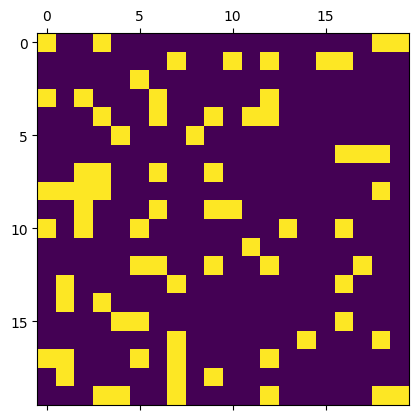

In [19]:
from matplotlib import pyplot as plt

plt.matshow(f1)



## Generate Network Connections w/ preferential attachment

##### Dynamics are pi = (ki)/SUM(ki) * e^(-a dist)

In [78]:
import plotly.graph_objects as go
import networkx as nx

def create_genet_network(forest):
    """
    tree list is a 2 x n matrix, of x,y coordinates
    """
    side = len(forest)
    tree_list = np.where(forest == 1)
    net = nx.Graph()


    for i in range(len(tree_list[0])):
        net.add_node(tree_list[1][i] + side * tree_list[0][i])

 
    return net

def propagate_genet_network(net,alpha,n_side):
    trees = list(net.nodes())
    n_trees = len(trees)

    for i in range(n_trees-1):
        tot_degree = max(2*net.number_of_edges(),2) #so not divide by 0
        for j in range(i+1,n_trees):
            pos1 = trees[i]
            pos2 = trees[j]
            x1 = int(pos1 % n_side)
            y1 = int( (pos1 - x1)/ n_side)
            x2 = int(pos2 % n_side)
            y2 = int( (pos2 - x2)/ n_side)

            dist = np.sqrt((x2-x1)**2 + (y2-y1)**2)
            deg1 = max(net.degree(pos1),1)
            deg2 = max(net.degree(pos2),1)


            r = np.random.rand()
            prob = np.exp(-1 * dist * alpha) #Distance component
            prob *= (deg1 + deg2) / (tot_degree)
            if r < ( prob):
                net.add_edge(pos1,pos2)
                tot_degree += 2


    return net

 

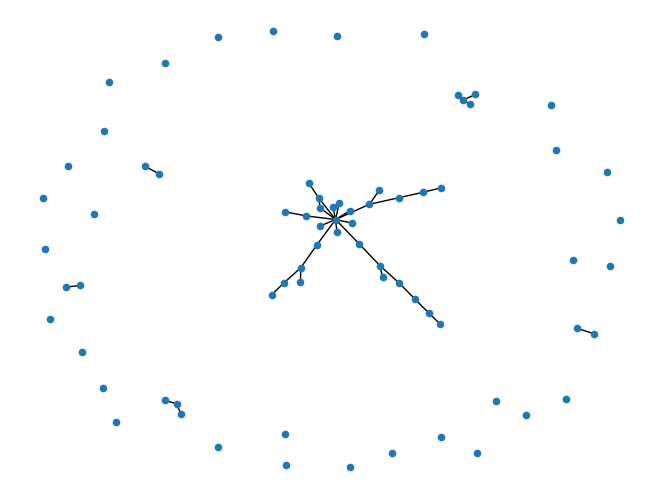

In [79]:
net = create_genet_network(f1)



for i in range(1):
    propagate_genet_network(net,.1,10)

nx.draw(net,node_size = 20)



## Define Basic Nutrient Map

In [80]:
## Set up Nutrient map

def create_nutrient_layout(side_length,mu,sigma):
    nut = np.random.normal(mu,sigma,(side_length,side_length))
    nut = np.where(nut < 0, 0, nut)
    return nut

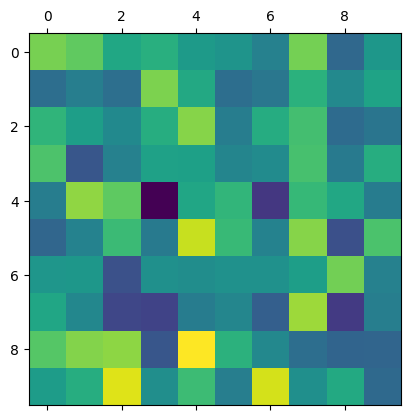

In [81]:
nutrient_map = create_nutrient_layout(10,3,1)
plt.matshow(nutrient_map)

## Transfer Dynamics